# Deployment Pipeline

## Objective

The objective of this notebook is to prepare the trained anomaly detection model for deployment in an industrial environment.

This notebook demonstrates:

- Loading the production-ready model
- Building an inference pipeline
- Predicting new observations
- Producing probability scores
- Generating prediction reports
- Saving deployment artifacts

Unlike previous notebooks that focused on model development, this notebook focuses on production inference.

The resulting pipeline can later be integrated into:

- SCADA Systems
- PLC Monitoring
- Industrial IoT Platforms
- REST APIs
- Edge AI Devices

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

MODEL_PATH = PROJECT_ROOT/"models"/"best_model.pkl"

DATA_PATH = PROJECT_ROOT/"data"/"processed"

RESULT_PATH = PROJECT_ROOT/"results"

DEPLOY_PATH = PROJECT_ROOT/"deployment"

DEPLOY_PATH.mkdir(exist_ok=True)

RESULT_PATH.mkdir(exist_ok=True)

In [3]:
model = joblib.load(MODEL_PATH)

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [4]:
test = pd.read_csv(
    DATA_PATH/"test_data.csv"
)

X_test = test.drop(columns="Target")

y_test = test["Target"]

print(X_test.shape)

(288344, 51)


In [5]:
incoming_data = X_test.sample(
    1000,
    random_state=42
)

incoming_data.head()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603
201504,0.737954,-0.258220,0.335952,-1.648125,-0.046608,-0.308700,1.650307,-0.684840,-1.651437,-3.020295,...,0.170397,0.165048,0.0,0.096696,-1.101153,0.068147,-0.099023,0.0,-0.091453,0.0
117688,-1.565178,1.777068,0.335952,-1.648125,-0.046608,-0.248022,-0.053036,2.237549,-1.651437,0.321655,...,0.196113,0.165048,0.0,0.249410,-0.407415,0.271031,-0.098602,0.0,-0.091453,0.0
140536,-1.565178,1.777702,0.335952,-1.648125,-0.046608,-0.248022,-0.256458,2.086069,-1.651437,0.321655,...,0.220542,0.165048,0.0,0.226398,-0.354050,0.253177,-0.098602,0.0,-0.091453,0.0
125075,0.540614,-0.453641,0.335952,0.606750,-0.046608,3.048082,-0.497860,-0.261863,0.595063,0.321655,...,-6.012755,-6.058857,0.0,-2.091530,-3.769375,-1.712899,-0.098181,0.0,-0.091453,0.0
1174,-1.565178,0.802815,-2.880775,0.606750,-0.046608,2.858476,-0.286295,-0.110385,0.620938,0.321655,...,0.178112,0.165048,0.0,0.182468,1.246884,0.171481,-0.098181,0.0,-0.091453,0.0


In [6]:
prediction = model.predict(
    incoming_data
)

probability = model.predict_proba(
    incoming_data
)[:,1]

In [7]:
prediction_report = incoming_data.copy()

prediction_report["Prediction"] = prediction

prediction_report["Anomaly Probability"] = probability

In [8]:
conditions = [

    prediction_report["Anomaly Probability"] < .30,

    prediction_report["Anomaly Probability"] < .60,

    prediction_report["Anomaly Probability"] < .85,

    prediction_report["Anomaly Probability"] >= .85

]

choices = [

    "Normal",

    "Low Risk",

    "Medium Risk",

    "High Risk"

]

prediction_report["Risk Level"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

In [9]:
prediction_report["Risk Level"].value_counts()

Risk Level
Normal         956
High Risk       40
Low Risk         3
Medium Risk      1
Name: count, dtype: int64

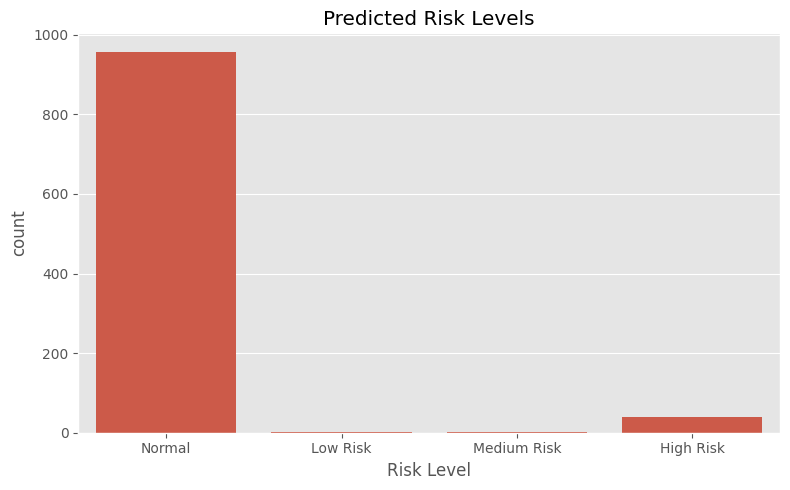

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=prediction_report,

    x="Risk Level",

    order=[
        "Normal",
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]

)

plt.title("Predicted Risk Levels")

plt.tight_layout()

plt.savefig(

    RESULT_PATH/"risk_levels.png",

    dpi=300

)

plt.show()

In [11]:
prediction_report.sort_values(

    "Anomaly Probability",

    ascending=False

).head(20)

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Prediction,Anomaly Probability,Risk Level
66885,-1.565178,1.780552,-2.880775,-1.648125,-0.046608,-0.484649,1.623187,-0.440726,-1.651437,-3.020295,...,-6.141207,-3.769375,-6.135755,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
164283,-1.565178,1.784037,-2.880775,-1.648125,-0.046608,-0.484649,1.634038,-0.447717,-1.651437,-3.020295,...,-6.139115,-3.769375,-6.134673,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
31875,-1.565178,1.777384,-2.880775,-1.648125,-0.046608,-0.431560,1.541816,-0.161654,-1.651437,-3.020295,...,-6.139952,-3.769375,-6.136837,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
89796,-1.565178,1.778652,-2.880775,-1.648125,-0.046608,-0.263194,1.059020,0.477473,-1.651437,-3.020295,...,-6.149575,-3.769375,-6.148740,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
169918,-1.565178,1.770734,-2.880775,-1.648125,-0.046608,-0.273812,1.064437,0.496699,-1.651437,-3.020295,...,-6.149993,-3.769375,-6.147658,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
12615,-1.565178,1.779286,-2.880775,-1.648125,-0.046608,-0.034146,0.804057,0.690128,-1.651437,-3.020295,...,-6.155851,-3.769375,-6.156314,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
116826,-1.565178,1.769784,-2.880775,-1.648125,-0.046608,-0.477066,1.587923,-0.212341,-1.651437,-3.020295,...,-6.140789,-3.769375,-6.135214,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
222935,-1.565178,1.777702,-2.880775,-1.648125,-0.046608,-0.276842,1.202775,0.383089,-1.651437,-3.020295,...,-6.146228,-3.769375,-6.145493,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
52247,-1.565178,1.777702,-2.880775,-1.648125,-0.046608,-0.269258,1.422474,0.125575,-1.651437,-3.020295,...,-6.144973,-3.769375,-6.139542,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk
77102,-1.565178,1.771050,-2.880775,-1.648125,-0.046608,-0.276842,1.316691,0.282299,-1.651437,-3.020295,...,-6.146228,-3.769375,-6.142788,-0.099023,0.0,-0.091453,0.0,1,1.0,High Risk


In [12]:
prediction_report.to_csv(

    DEPLOY_PATH/"prediction_report.csv",

    index=False

)

In [13]:
joblib.dump(

    model,

    DEPLOY_PATH/"industrial_anomaly_detector.pkl"

)

['E:\\new\\hamid\\CV\\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\\deployment\\industrial_anomaly_detector.pkl']

In [14]:
def predict_sample(dataframe):

    probability = model.predict_proba(dataframe)[:,1]

    prediction = model.predict(dataframe)

    result = dataframe.copy()

    result["Prediction"] = prediction

    result["Probability"] = probability

    return result

In [15]:
predict_sample(

    incoming_data.head(10)

)

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Prediction,Probability
201504,0.737954,-0.258220,0.335952,-1.648125,-0.046608,-0.308700,1.650307,-0.684840,-1.651437,-3.020295,...,0.0,0.096696,-1.101153,0.068147,-0.099023,0.0,-0.091453,0.0,0,0.288909
117688,-1.565178,1.777068,0.335952,-1.648125,-0.046608,-0.248022,-0.053036,2.237549,-1.651437,0.321655,...,0.0,0.249410,-0.407415,0.271031,-0.098602,0.0,-0.091453,0.0,0,0.000000
140536,-1.565178,1.777702,0.335952,-1.648125,-0.046608,-0.248022,-0.256458,2.086069,-1.651437,0.321655,...,0.0,0.226398,-0.354050,0.253177,-0.098602,0.0,-0.091453,0.0,0,0.000000
125075,0.540614,-0.453641,0.335952,0.606750,-0.046608,3.048082,-0.497860,-0.261863,0.595063,0.321655,...,0.0,-2.091530,-3.769375,-1.712899,-0.098181,0.0,-0.091453,0.0,1,0.998916
1174,-1.565178,0.802815,-2.880775,0.606750,-0.046608,2.858476,-0.286295,-0.110385,0.620938,0.321655,...,0.0,0.182468,1.246884,0.171481,-0.098181,0.0,-0.091453,0.0,0,0.020945
80368,-1.565178,1.209493,0.335952,0.606750,-0.046608,-0.248022,-0.389369,-0.146506,0.615740,0.321655,...,0.0,0.148158,1.887255,0.143349,-0.098181,0.0,-0.091453,0.0,0,0.027518
156948,-1.565178,0.354330,0.335952,0.606750,-0.046608,-0.248022,-0.731111,-0.007262,0.619520,0.321655,...,0.0,0.351918,1.567071,0.390595,-0.097340,0.0,-0.091453,0.0,0,0.000000
143161,0.709643,-0.524271,0.335952,0.606750,-0.046608,2.800832,-0.408355,-0.184375,0.603570,0.321655,...,0.0,0.084979,-0.514144,0.064902,-0.099023,0.0,-0.091453,0.0,0,0.015199
55637,0.678002,0.419892,0.335952,-1.648125,-0.046608,-0.910887,2.019178,-0.863121,-1.651437,-3.020295,...,0.0,0.118870,-0.514144,0.083835,-0.099023,0.0,-0.091453,0.0,0,0.095776
133567,0.542279,1.292792,0.335952,-1.648125,-0.046608,-1.065601,2.089705,-0.941191,-1.651437,-3.020295,...,0.0,0.160709,-1.047789,0.128200,-0.099023,0.0,-0.091453,0.0,0,0.020558


In [16]:
summary = pd.DataFrame({

    "Metric":[

        "Samples",

        "Predicted Normal",

        "Predicted Attack",

        "Average Probability"

    ],

    "Value":[

        len(prediction_report),

        (prediction==0).sum(),

        (prediction==1).sum(),

        prediction_report["Anomaly Probability"].mean()

    ]

})

summary

,Metric,Value
0,Samples,1000.000000
1,Predicted Normal,959.000000
2,Predicted Attack,41.000000
3,Average Probability,0.052273


In [17]:
summary.to_csv(

    DEPLOY_PATH/"deployment_summary.csv",

    index=False

)

In [18]:
pipeline = [

    "Sensor Data",

    "Preprocessing",

    "Feature Engineering",

    "ML Model",

    "Probability",

    "Risk Assessment",

    "Alarm"

]

for step in pipeline:

    print(step)

Sensor Data
Preprocessing
Feature Engineering
ML Model
Probability
Risk Assessment
Alarm


# Conclusions

A production-ready deployment pipeline has been successfully developed.

The trained machine learning model can now receive new sensor observations and produce:

- Binary predictions
- Anomaly probabilities
- Risk categories
- Deployment reports

The deployment artifacts generated in this notebook can be integrated into industrial monitoring systems or further wrapped into REST APIs, edge applications, or cloud services.

This notebook completes the end-to-end lifecycle of the anomaly detection project, from data understanding to production-ready inference.